# c5tree speed and accuracy benchmark

This temporary benchmark compares three estimators on identical stratified train/test splits:

- `c5tree==0.1.0` from PyPI, representing the older pure-Python release
- the locally built `c5tree 0.2.0` wheel with the C++ numeric splitter
- scikit-learn's `DecisionTreeClassifier`

The benchmark measures fit time, prediction time, accuracy, tree depth, and leaf count. It is not a LightGBM benchmark: LightGBM uses a different gradient-boosting algorithm, so its accuracy and speed are not directly equivalent to C5.0.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import tempfile

import pandas as pd

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((path for path in candidates if (path / 'pyproject.toml').exists()), None)
if ROOT is None:
    raise RuntimeError(
        'Could not locate the c5tree repository. Run this notebook from the project workspace.'
    )

wheels = sorted((ROOT / 'dist').glob('c5tree-0.2.0-*.whl'))
if not wheels:
    raise FileNotFoundError(
        f'No c5tree 0.2.0 wheel found in {ROOT / "dist"}. '
        'Build it first with: .venv\\Scripts\\python.exe -m build'
    )
WHEEL = wheels[-1]
OLD_VERSION = 'c5tree==0.1.0'
REPEATS = 5
print(f'Python: {sys.executable}')
print(f'Repository: {ROOT}')
print(f'New wheel: {WHEEL}')

Python: d:\practice_projects\c5tree\.venv\Scripts\python.exe
Repository: d:\practice_projects\c5tree
New wheel: d:\practice_projects\c5tree\dist\c5tree-0.2.0-cp311-cp311-win_amd64.whl


In [2]:
RUNNER = r'''
import json
import sys
from time import perf_counter

import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

package_name = sys.argv[1]
repeats = int(sys.argv[2])
datasets = {
    'iris': load_iris,
    'wine': load_wine,
    'breast_cancer': load_breast_cancer,
}

def make_model():
    if package_name == 'sklearn':
        return DecisionTreeClassifier(random_state=42)
    from c5tree import C5Classifier
    return C5Classifier(pruning=True, cf=0.25)

results = []
for dataset_name, loader in datasets.items():
    X, y = loader(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    for repeat in range(repeats):
        model = make_model()
        started = perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = perf_counter() - started
        started = perf_counter()
        predictions = model.predict(X_test)
        predict_seconds = perf_counter() - started
        row = {
            'estimator': package_name,
            'dataset': dataset_name,
            'repeat': repeat,
            'fit_seconds': fit_seconds,
            'predict_seconds': predict_seconds,
            'accuracy': float(np.mean(predictions == y_test)),
        }
        if hasattr(model, 'get_depth'):
            row['depth'] = int(model.get_depth())
        else:
            row['depth'] = None
        if hasattr(model, 'get_n_leaves'):
            row['leaves'] = int(model.get_n_leaves())
        else:
            row['leaves'] = int(model.get_n_leaves())
        results.append(row)

print(json.dumps(results))
'''

runner_path = Path(tempfile.mkdtemp(prefix='c5tree-benchmark-')) / 'runner.py'
runner_path.write_text(RUNNER, encoding='utf-8')
print(runner_path)

C:\Users\vinay\AppData\Local\Temp\c5tree-benchmark-h65tdod8\runner.py


In [3]:
def install_into_target(requirement, target):
    target.mkdir(parents=True, exist_ok=True)
    command = [
        sys.executable, '-m', 'pip', 'install', '--quiet',
        '--no-deps', '--target', str(target), requirement,
    ]
    subprocess.run(command, check=True)

old_target = Path(tempfile.mkdtemp(prefix='c5tree-old-'))
new_target = Path(tempfile.mkdtemp(prefix='c5tree-new-'))
install_into_target(OLD_VERSION, old_target)
install_into_target(str(WHEEL), new_target)
print(f'Old package target: {old_target}')
print(f'New package target: {new_target}')

Old package target: C:\Users\vinay\AppData\Local\Temp\c5tree-old-_3vvo1tk
New package target: C:\Users\vinay\AppData\Local\Temp\c5tree-new-cb3l2fh6


In [4]:
def run_benchmark(estimator, package_target=None):
    environment = os.environ.copy()
    environment['PYTHONNOUSERSITE'] = '1'
    if package_target is not None:
        environment['PYTHONPATH'] = str(package_target)
    completed = subprocess.run(
        [sys.executable, str(runner_path), estimator, str(REPEATS)],
        cwd=runner_path.parent,
        env=environment,
        check=True,
        capture_output=True,
        text=True,
    )
    return json.loads(completed.stdout.strip().splitlines()[-1])

rows = []
rows.extend(run_benchmark('old_pypi', old_target))
rows.extend(run_benchmark('new_cpp', new_target))
rows.extend(run_benchmark('sklearn'))
results = pd.DataFrame(rows)
results.head()

,estimator,dataset,repeat,fit_seconds,predict_seconds,accuracy,depth,leaves
0,old_pypi,iris,0,0.011149,0.000155,0.933333,5,8
1,old_pypi,iris,1,0.011005,0.000139,0.933333,5,8
2,old_pypi,iris,2,0.011102,0.000131,0.933333,5,8
3,old_pypi,iris,3,0.010629,0.000127,0.933333,5,8
4,old_pypi,iris,4,0.011004,0.000129,0.933333,5,8


In [5]:
summary = (
    results.groupby(['dataset', 'estimator'], as_index=False)
    .agg(
        fit_seconds=('fit_seconds', 'mean'),
        predict_seconds=('predict_seconds', 'mean'),
        accuracy=('accuracy', 'mean'),
        fit_std=('fit_seconds', 'std'),
        depth=('depth', 'mean'),
        leaves=('leaves', 'mean'),
    )
    .sort_values(['dataset', 'fit_seconds'])
)
summary

,dataset,estimator,fit_seconds,predict_seconds,accuracy,fit_std,depth,leaves
2,breast_cancer,sklearn,0.004267,0.000153,0.912281,0.000064,7.0,19.0
0,breast_cancer,new_cpp,0.037548,0.001332,0.912281,0.000877,13.0,22.0
1,breast_cancer,old_pypi,2.125863,0.001327,0.912281,0.011893,13.0,22.0
5,iris,sklearn,0.000774,0.000143,0.933333,0.000154,5.0,8.0
3,iris,new_cpp,0.003383,0.000134,0.933333,0.000339,5.0,8.0
4,iris,old_pypi,0.010978,0.000136,0.933333,0.000205,5.0,8.0
8,wine,sklearn,0.000931,0.000146,0.944444,0.000026,4.0,8.0
6,wine,new_cpp,0.003068,0.000172,0.972222,0.000097,4.0,6.0
7,wine,old_pypi,0.070037,0.000195,0.972222,0.003354,4.0,6.0


In [6]:
CV_RUNNER = r'''
import json
import sys

import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris, load_wine
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

package_name = sys.argv[1]
datasets = {
    'iris': load_iris,
    'wine': load_wine,
    'breast_cancer': load_breast_cancer,
}


def make_model():
    if package_name == 'sklearn':
        return DecisionTreeClassifier(random_state=42)
    from c5tree import C5Classifier
    return C5Classifier(pruning=True, cf=0.25)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for dataset_name, loader in datasets.items():
    X, y = loader(return_X_y=True)
    scores = cross_val_score(make_model(), X, y, cv=cv, scoring='accuracy')
    results.append({
        'estimator': package_name,
        'dataset': dataset_name,
        'accuracy_mean': float(np.mean(scores)),
        'accuracy_std': float(np.std(scores)),
    })

print(json.dumps(results))
'''
cv_runner_path = runner_path.parent / 'cv_runner.py'
cv_runner_path.write_text(CV_RUNNER, encoding='utf-8')


def run_cv(estimator, package_target=None):
    environment = os.environ.copy()
    environment['PYTHONNOUSERSITE'] = '1'
    if package_target is not None:
        environment['PYTHONPATH'] = str(package_target)
    completed = subprocess.run(
        [sys.executable, str(cv_runner_path), estimator],
        cwd=cv_runner_path.parent,
        env=environment,
        check=True,
        capture_output=True,
        text=True,
    )
    return json.loads(completed.stdout.strip().splitlines()[-1])

cv_rows = []
cv_rows.extend(run_cv('old_pypi', old_target))
cv_rows.extend(run_cv('new_cpp', new_target))
cv_rows.extend(run_cv('sklearn'))
cv_summary = pd.DataFrame(cv_rows).sort_values(['dataset', 'accuracy_mean'], ascending=[True, False])
cv_summary

,estimator,dataset,accuracy_mean,accuracy_std
2,old_pypi,breast_cancer,0.920928,0.015624
5,new_cpp,breast_cancer,0.920928,0.015624
8,sklearn,breast_cancer,0.910402,0.027876
0,old_pypi,iris,0.960000,0.038873
3,new_cpp,iris,0.960000,0.038873
6,sklearn,iris,0.953333,0.033993
1,old_pypi,wine,0.904603,0.033305
4,new_cpp,wine,0.904603,0.033305
7,sklearn,wine,0.893175,0.038028


In [7]:
speed = summary.pivot(index='dataset', columns='estimator', values='fit_seconds')
speed['new_cpp_vs_old_speedup'] = speed['old_pypi'] / speed['new_cpp']
accuracy = summary.pivot(index='dataset', columns='estimator', values='accuracy')
display(speed)
display(accuracy)
print('Values above 1.0 in new_cpp_vs_old_speedup mean the C++ build is faster.')

estimator,new_cpp,old_pypi,sklearn,new_cpp_vs_old_speedup
dataset,,,,
breast_cancer,0.037548,2.125863,0.004267,56.616999
iris,0.003383,0.010978,0.000774,3.244869
wine,0.003068,0.070037,0.000931,22.828629


estimator,new_cpp,old_pypi,sklearn
dataset,,,
breast_cancer,0.912281,0.912281,0.912281
iris,0.933333,0.933333,0.933333
wine,0.972222,0.972222,0.944444


Values above 1.0 in new_cpp_vs_old_speedup mean the C++ build is faster.


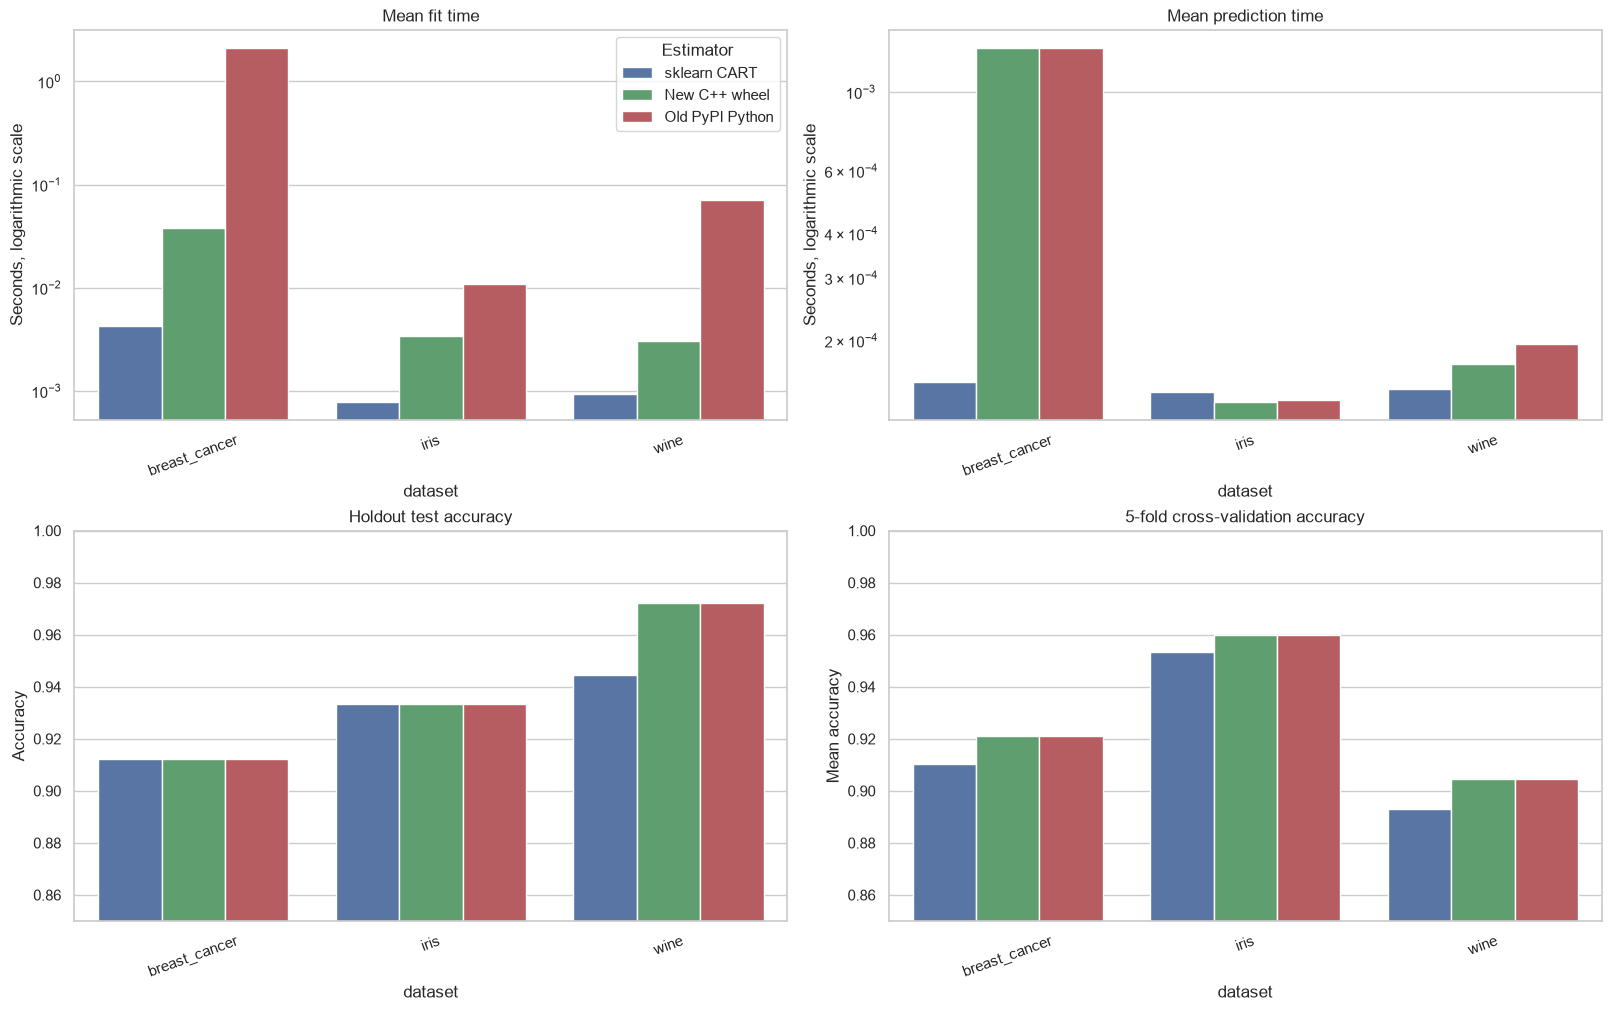

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
estimator_order = ['sklearn', 'new_cpp', 'old_pypi']
estimator_labels = {
    'sklearn': 'sklearn CART',
    'new_cpp': 'New C++ wheel',
    'old_pypi': 'Old PyPI Python',
}
estimator_palette = {
    'sklearn': '#4C72B0',
    'new_cpp': '#55A868',
    'old_pypi': '#C44E52',
}
plot_summary = summary.copy()
plot_summary['estimator'] = plot_summary['estimator'].map(estimator_labels)
plot_data = plot_summary.melt(
    id_vars=['dataset', 'estimator'],
    value_vars=['fit_seconds', 'predict_seconds'],
    var_name='metric',
    value_name='seconds',
)
plot_order = [estimator_labels[name] for name in estimator_order]
plot_palette = dict(zip(plot_order, [estimator_palette[name] for name in estimator_order]))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

sns.barplot(
    data=plot_data[plot_data['metric'] == 'fit_seconds'],
    x='dataset', y='seconds', hue='estimator', hue_order=plot_order,
    palette=plot_palette, ax=axes[0, 0], errorbar=None,
)
axes[0, 0].set_title('Mean fit time')
axes[0, 0].set_ylabel('Seconds, logarithmic scale')
axes[0, 0].set_yscale('log')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(title='Estimator')

sns.barplot(
    data=plot_data[plot_data['metric'] == 'predict_seconds'],
    x='dataset', y='seconds', hue='estimator', hue_order=plot_order,
    palette=plot_palette, ax=axes[0, 1], errorbar=None,
)
axes[0, 1].set_title('Mean prediction time')
axes[0, 1].set_ylabel('Seconds, logarithmic scale')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend_.remove()

sns.barplot(
    data=plot_summary,
    x='dataset', y='accuracy', hue='estimator', hue_order=plot_order,
    palette=plot_palette, ax=axes[1, 0], errorbar=None,
)
axes[1, 0].set_title('Holdout test accuracy')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0.85, 1.00)
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].legend_.remove()

plot_cv = cv_summary.copy()
plot_cv['estimator'] = plot_cv['estimator'].map(estimator_labels)
sns.barplot(
    data=plot_cv,
    x='dataset', y='accuracy_mean', hue='estimator', hue_order=plot_order,
    palette=plot_palette, ax=axes[1, 1], errorbar=None,
)
axes[1, 1].set_title('5-fold cross-validation accuracy')
axes[1, 1].set_ylabel('Mean accuracy')
axes[1, 1].set_ylim(0.85, 1.00)
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].legend_.remove()

plt.show()